<a href="https://colab.research.google.com/github/AlvaroAceval16/MachineLearning/blob/main/P6_XGBoost_Regresion_Autos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
# 1. Cargar Datos Y Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# Cargar el dataset

from google.colab import drive
drive.mount('/content/drive')
 # https://drive.google.com/file/d/1qNC76DVrW_w65ny-MxSf7ETqpG3lV9zf/view?usp=drive_link
file_id = '1qNC76DVrW_w65ny-MxSf7ETqpG3lV9zf'

#URL de descarga directa
url = f'https://drive.google.com/uc?id={file_id}'

#Leer el archivo CSV directamente desde la URL
df = pd.read_csv(url)

# --- Inicia la corrección del error ---
# Identificar columnas que deben ser numéricas y podrían contener '?'
numeric_cols = ['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore', 'price']

# Reemplazar '?' con NaN y convertir a numérico
for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].replace('?', np.nan)
        df[col] = pd.to_numeric(df[col])

# Imputar valores faltantes con la media
for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean())
# --- Termina la corrección del error ---

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
# 2. Definir variables predictoras y variable objetivo
X = df[['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore']]
y = df['price']

In [27]:
#  3. Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
# 4.  Entrenar modelo XGBoost
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)
xgb_model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [29]:
# 5. Evaluar el modelo
y_pred = xgb_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R²): {r2:.2f}")

Error cuadrático medio (MSE): 6128905.14
Coeficiente de determinación (R²): 0.92


In [30]:
# Calcular el RMSE (mas facil de interpretar que el MSE)
rmse = np.sqrt(mse)
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")

Raíz del Error cuadrático medio (RMSE): 2475.66


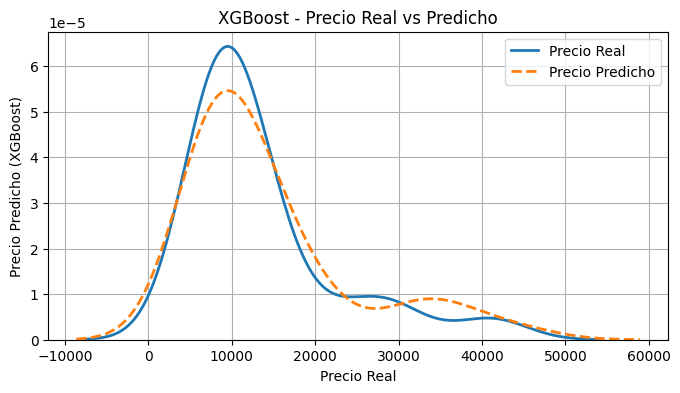

In [31]:
# 6. Comparar precios reales vs predichos
 #plt.scatter(y_test, y_pred, color='darkred')
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho (XGBoost)")
plt.title("XGBoost - Precio Real vs Predicho")
plt.legend()
plt.grid(True)
plt.show()

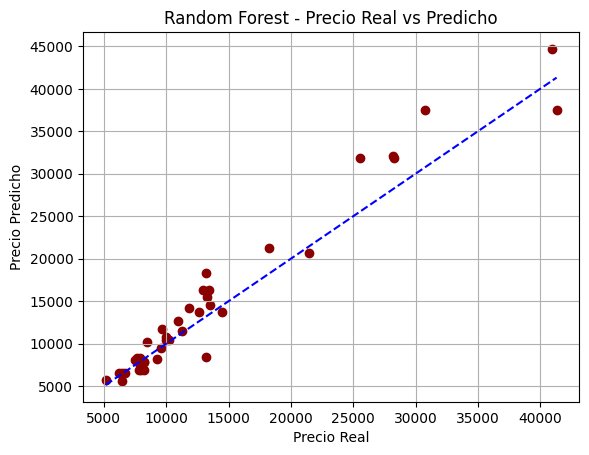

In [32]:
#  Comparar precios con diagrama de dispersión
plt.scatter(y_test, y_pred, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') # Línea ideal
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Random Forest - Precio Real vs Predicho")
plt.grid(True)
plt.show()

Error cuadrático medio (MSE): 6830199.62
Coeficiente de determinación (R²): 0.91
Raíz del Error cuadrático medio (RMSE): 2613.47




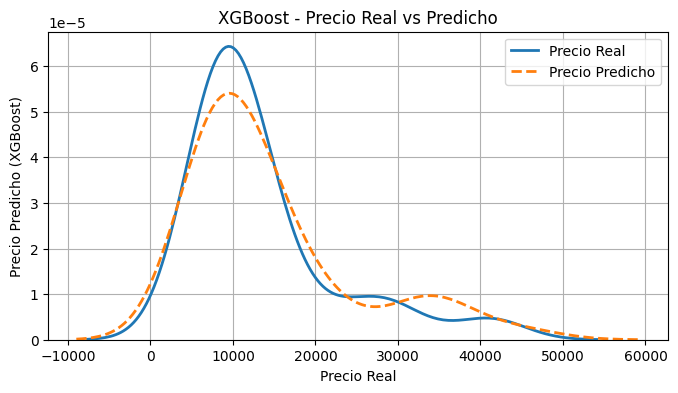

In [33]:
# Especificando parametros
xgb_model2 = XGBRegressor(
n_estimators=300,
learning_rate=0.05,
max_depth=6,
random_state=42
)
xgb_model2.fit(X_train, y_train)
# Evaluar
y_pred = xgb_model2.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)
# Calcular el RMSE (mas facil de interpretar que el MSE)
rmse = np.sqrt(mse)
print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R²): {r2:.2f}")
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")
print("\n")
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho (XGBoost)")
plt.title("XGBoost - Precio Real vs Predicho")
plt.legend()
plt.grid(True)
plt.show()

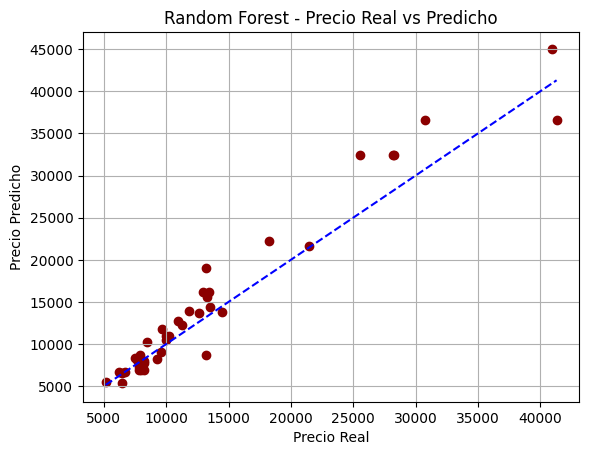

In [34]:
# Diagrama de Dispersion
plt.scatter(y_test, y_pred, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') # Línea ideal
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Random Forest - Precio Real vs Predicho")
plt.grid(True)
plt.show()

In [35]:
# Búsqueda de mejores parámetros
from sklearn.model_selection import GridSearchCV
# Definición del modelo base (usa XGBRegressor, no es necesario pasar parámetros aquí)
xgb_base = XGBRegressor(random_state=42, eval_metric='rmse')
# Nota: eval_metric='rmse' se usa para evitar advertencias de XGBoost
# Definición de la rejilla
param_grid = {
'n_estimators': [100, 300, 500],
'learning_rate': [0.01, 0.05, 0.1],
'max_depth': [3, 5, 7],
'min_child_weight': [1, 5, 10],
'subsample': [0.7, 0.9],
'colsample_bytree': [0.7, 0.9]
}
# Inicialización de Grid Search
grid_search_xgb = GridSearchCV(
estimator=xgb_base,
param_grid=param_grid,
scoring='r2',
cv=5, # Es mejor usar cv=5 para más robustez en XGBoost
n_jobs=-1,
verbose=2
)
# Ejecución del ajuste
grid_search_xgb.fit(X_train, y_train)
# Evalúar con:
print("Mejores Parámetros:", grid_search_xgb.best_params_)
best_xgb = grid_search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
r2_xgb = r2_score(y_test, y_pred_xgb)



Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Mejores Parámetros: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 0.9}


Error cuadrático medio (MSE): 6239191.55
Coeficiente de determinación (R²): 0.92
Raíz del Error cuadrático medio (RMSE): 2497.84




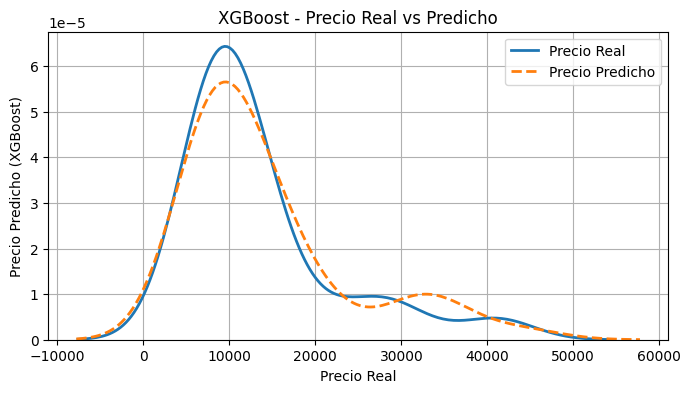

In [36]:
# Reentrenar el modelo XGBoost con Los hiperparámetros seleccionados por GridSearch(Óptimos)

# 1. Crear el modelo final con los parámetros óptimos
best_xgb_model = XGBRegressor(
colsample_bytree=0.7,
learning_rate=0.05,
max_depth=7,
min_child_weight=1,
n_estimators=300,
subsample=0.9,
random_state=42,
eval_metric='rmse'
)
# 2. Entrenar el modelo final
best_xgb_model.fit(X_train, y_train)
# 3. Evaluar
y_pred = best_xgb_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# Calcular el RMSE (mas facil de interpretar que el MSE)
rmse = np.sqrt(mse)
print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R²): {r2:.2f}")
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")
print("\n")
plt.figure(figsize=(8, 4))

sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho (XGBoost)")
plt.title("XGBoost - Precio Real vs Predicho")
plt.legend()
plt.grid(True)
plt.show()


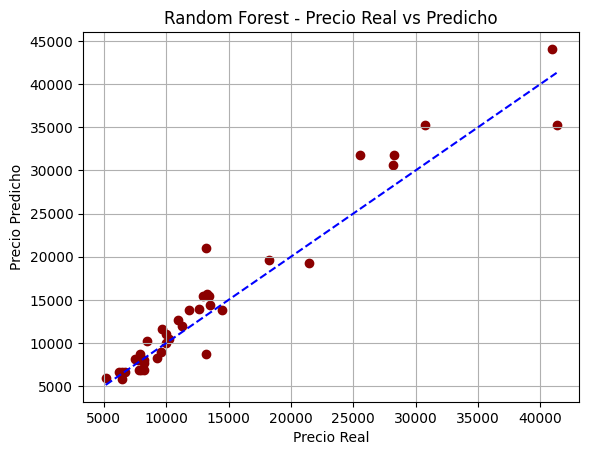

In [37]:
plt.scatter(y_test, y_pred, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') # Línea ideal
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Random Forest - Precio Real vs Predicho")
plt.grid(True)
plt.show()